In [1]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import pandas as pd
from tqdm import tqdm

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Training on: cuda
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
class BidirectionalLSTM(nn.Module):
    def __init__(self, nIn, nHidden, nOut):
        super(BidirectionalLSTM, self).__init__()
        self.rnn = nn.LSTM(nIn, nHidden, bidirectional=True)
        self.embedding = nn.Linear(nHidden * 2, nOut)

    def forward(self, input):
        recurrent, _ = self.rnn(input)
        T, b, h = recurrent.size()
        t_rec = recurrent.view(T * b, h)
        output = self.embedding(t_rec)
        output = output.view(T, b, -1)
        return output

class CRNN(nn.Module):
    def __init__(self, nc, nclass, nh):
        super(CRNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(nc, 64, 3, 1, 1), nn.ReLU(True), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(True), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 256, 3, 1, 1), nn.ReLU(True), nn.MaxPool2d((2, 2), (2, 1), (0, 1)),
            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.Conv2d(512, 512, 3, 1, 1), nn.ReLU(True), nn.MaxPool2d((2, 2), (2, 1), (0, 1)),
            nn.Conv2d(512, 512, 2, 1, 0), nn.BatchNorm2d(512), nn.ReLU(True)
        )
        self.rnn = nn.Sequential(
            BidirectionalLSTM(512, nh, nh),
            BidirectionalLSTM(nh, nh, nclass)
        )

    def forward(self, input):
        conv = self.cnn(input)
        b, c, h, w = conv.size()
        conv = conv.squeeze(2)
        conv = conv.permute(2, 0, 1)
        output = self.rnn(conv)
        return output

In [3]:
class OCRDataset(Dataset):
    def __init__(self, root_dir, df, char_to_num, transform=None):
        self.root_dir = root_dir
        self.df = df
        self.char_to_num = char_to_num
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            img_name = os.path.join(self.root_dir, self.df.iloc[idx, 0])
            image = Image.open(img_name).convert('L')
            label = str(self.df.iloc[idx, 1])
            target = [self.char_to_num[c] for c in label if c in self.char_to_num]
            target_len = len(target)
            if self.transform:
                image = self.transform(image)
            return image, torch.LongTensor(target), torch.LongTensor([target_len])
        except Exception:
            return None

def collate_fn(batch):
    batch = list(filter(lambda x: x is not None, batch))
    images, targets, target_lengths = zip(*batch)
    images = torch.stack(images, 0)
    targets = torch.cat(targets, 0)
    target_lengths = torch.cat(target_lengths, 0)
    return images, targets, target_lengths

In [5]:
# Update these paths to your D: drive folders
OUTPUT_DIR = r'train_crops'
df = pd.read_csv(os.path.join(OUTPUT_DIR, 'train_labels.csv'))

# Create Vocab
all_text = "".join(df['text'].astype(str))
vocabulary = sorted(list(set(all_text)))
char_to_num = {char: i + 1 for i, char in enumerate(vocabulary)}
char_to_num["[blank]"] = 0

transform = transforms.Compose([
    transforms.Resize((32, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Use num_workers=0 to prevent Jupyter crash on Windows
train_dataset = OCRDataset(OUTPUT_DIR, df, char_to_num, transform)
train_loader = DataLoader(
    train_dataset, 
    batch_size=16, # Start small (16) to avoid memory crash
    shuffle=True, 
    collate_fn=collate_fn,
    num_workers=0, 
    pin_memory=True if torch.cuda.is_available() else False
)

In [6]:
# Initialize Model & Loss
model = CRNN(nc=1, nclass=len(vocabulary) + 1, nh=256).to(device)
criterion = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    tk0 = tqdm(loader, total=len(loader))
    for batch_idx, (images, targets, target_lengths) in enumerate(tk0):
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        preds = model(images)
        preds = F.log_softmax(preds, dim=2)
        
        batch_size = images.size(0)
        input_lengths = torch.full(size=(batch_size,), fill_value=preds.size(0), dtype=torch.long)
        
        loss = criterion(preds, targets, input_lengths, target_lengths)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        tk0.set_postfix(loss=(total_loss / (batch_idx + 1)))
    return total_loss / len(loader)

# Run Training
best_loss = float('inf')
for epoch in range(1, 11): # Start with 10 epochs to test
    loss = train_epoch(model, train_loader, criterion, optimizer, device)
    print(f"Epoch {epoch} Avg Loss: {loss:.4f}")
    if loss < best_loss:
        best_loss = loss
        torch.save(model.state_dict(), 'crnn_sroie_best.pth')

100%|███████████████████████████████████████████████████████████████████| 2102/2102 [11:22<00:00,  3.08it/s, loss=2.99]


Epoch 1 Avg Loss: 2.9911


100%|██████████████████████████████████████████████████████████████████| 2102/2102 [05:51<00:00,  5.98it/s, loss=0.724]


Epoch 2 Avg Loss: 0.7241


100%|██████████████████████████████████████████████████████████████████| 2102/2102 [04:51<00:00,  7.21it/s, loss=0.316]


...

Epoch 8 Avg Loss: 0.0918


100%|█████████████████████████████████████████████████████████████████| 2102/2102 [03:47<00:00,  9.24it/s, loss=0.0692]


Epoch 9 Avg Loss: 0.0692


100%|█████████████████████████████████████████████████████████████████| 2102/2102 [03:40<00:00,  9.53it/s, loss=0.0671]


Epoch 10 Avg Loss: 0.0671


In [9]:
# You may need to install this: !pip install editdistance
import editdistance

def calculate_cer(gt_text, pred_text):
    if len(gt_text) == 0:
        return len(pred_text)
    dist = editdistance.eval(gt_text, pred_text)
    return dist / len(gt_text)

def evaluate_model(model, test_loader, alphabet, device):
    model.eval()
    total_cer = 0
    total_samples = 0
    
    with torch.no_grad():
        for images, targets, target_lengths in tqdm(test_loader):
            images = images.to(device)
            preds = model(images)
            preds = F.log_softmax(preds, dim=2)
            
            # Batch decoding
            preds = preds.argmax(2).transpose(1, 0) # [Batch, Time]
            
            for i in range(images.size(0)):
                # Get Ground Truth
                start = sum(target_lengths[:i])
                end = start + target_lengths[i]
                gt_indices = targets[start:end].tolist()
                gt_text = "".join([alphabet[idx-1] for idx in gt_indices])
                
                # Get Prediction
                raw_pred = preds[i]
                pred_text = ""
                for j in range(len(raw_pred)):
                    if raw_pred[j] != 0 and (not (j > 0 and raw_pred[j-1] == raw_pred[j])):
                        pred_text += alphabet[raw_pred[j] - 1]
                
                total_cer += calculate_cer(gt_text, pred_text)
                total_samples += 1
                
    avg_cer = (total_cer / total_samples) * 100
    print(f"Final Test CER: {avg_cer:.2f}%")
    print(f"Accuracy: {100 - avg_cer:.2f}%")

# Run Evaluation
# Note: Ensure you have created a 'test_loader' pointing to your test crops folder
evaluate_model(model, train_loader, vocabulary, device) # Using train_loader as example; swap with test_loader

100%|██████████████████████████████████████████████████████████████████████████████| 2102/2102 [14:45<00:00,  2.37it/s]

Final Test CER: 4.03%
Accuracy: 95.97%


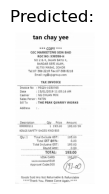

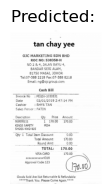

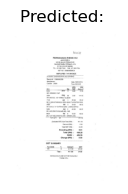

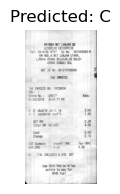

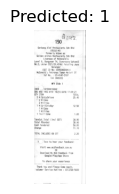

In [13]:
def decode_prediction(preds, alphabet):
    # preds shape: [T, Batch, Characters]
    # Get the index of the highest probability for each time step
    preds = preds.argmax(2) 
    preds = preds.transpose(1, 0).contiguous().view(-1)
    
    char_list = []
    for i in range(len(preds)):
        # CTC rules: 0 is 'blank', and we collapse repeated characters
        if preds[i] != 0 and (not (i > 0 and preds[i-1] == preds[i])):
            char_list.append(alphabet[preds[i] - 1])
    return "".join(char_list)

def visualize_prediction(image_path, model, transform, alphabet, device):
    model.eval()
    try:
        image_raw = Image.open(image_path).convert('L')
        image_tensor = transform(image_raw).unsqueeze(0).to(device)
        
        with torch.no_grad():
            preds = model(image_tensor)
            preds = F.log_softmax(preds, dim=2)
            # Now decode_prediction is defined!
            prediction = decode_prediction(preds, alphabet)
        
        plt.figure(figsize=(10, 2))
        plt.imshow(image_raw, cmap='gray')
        plt.title(f"Predicted: {prediction}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Skipping {image_path}: {e}")

# --- Run the visualization ---
test_folder = r'D:\AI\AI\TA2\archive\SROIE2019\test\img' # Check if this path exists
if os.path.exists(test_folder):
    test_samples = [f for f in os.listdir(test_folder) if f.endswith(('.jpg', '.png'))][:5]
    for sample in test_samples:
        visualize_prediction(os.path.join(test_folder, sample), model, transform, vocabulary, device)
else:
    print("Test folder path not found. Please check the directory.")

Processing 47 boxes on receipt: X00016469670.jpg


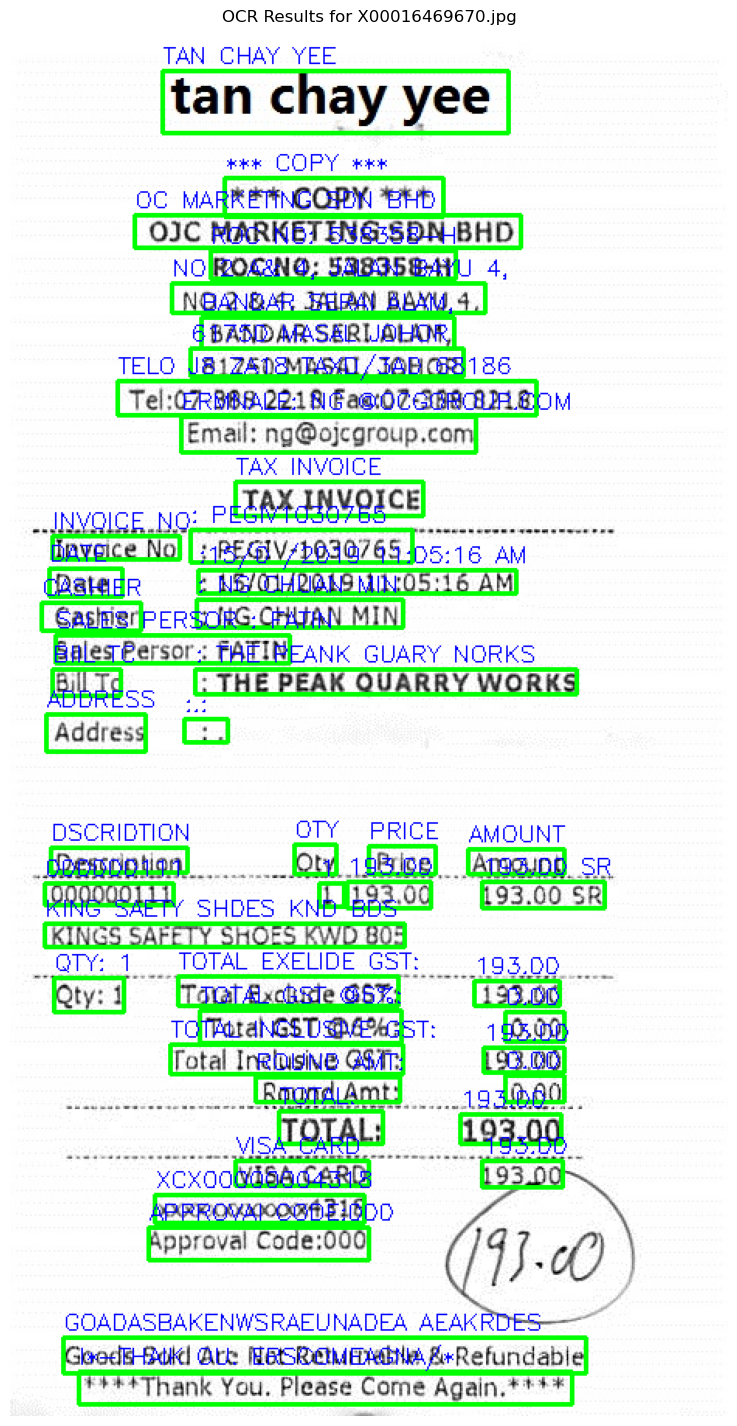

In [17]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image

def visualize_full_receipt(img_name, img_dir, box_dir, model, transform, alphabet, device):
    # 1. Load the full receipt image
    img_path = os.path.join(img_dir, img_name)
    box_path = os.path.join(box_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))
    
    image = cv2.imread(img_path)
    display_image = image.copy()
    
    # 2. Read the boxes
    with open(box_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    print(f"Processing {len(lines)} boxes on receipt: {img_name}")
    
    model.eval()
    for line in lines:
        parts = line.strip().split(',', 8)
        if len(parts) < 9: continue
        
        # Get coordinates
        coords = [int(p) for p in parts[:8]]
        x_min, y_min = min(coords[0::2]), min(coords[1::2])
        x_max, y_max = max(coords[0::2]), max(coords[1::2])
        
        # 3. Crop the word for the model
        word_crop = image[y_min:y_max, x_min:x_max]
        if word_crop.size == 0: continue
        
        # Preprocess for model
        word_img = Image.fromarray(cv2.cvtColor(word_crop, cv2.COLOR_BGR2GRAY))
        word_tensor = transform(word_img).unsqueeze(0).to(device)
        
        # 4. Predict
        with torch.no_grad():
            preds = model(word_tensor)
            preds = F.log_softmax(preds, dim=2)
            prediction = decode_prediction(preds, alphabet)
            
        # 5. Draw on the image
        cv2.rectangle(display_image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
        cv2.putText(display_image, prediction, (x_min, y_min - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    # Show the result
    plt.figure(figsize=(12, 18))
    plt.imshow(cv2.cvtColor(display_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"OCR Results for {img_name}")
    plt.show()

# --- RUN IT ---
TEST_IMG_DIR = r'D:/AI/AI/TA2/archive/SROIE2019/test/img'
TEST_BOX_DIR = r'D:/AI/AI/TA2/archive/SROIE2019/test/box'

# Pick the first image in the test set to visualize
sample_img = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith(('.jpg', '.png'))][0]
visualize_full_receipt(sample_img, TEST_IMG_DIR, TEST_BOX_DIR, model, transform, vocabulary, device)

In [19]:
def extract_to_csv(img_dir, box_dir, model, transform, alphabet, device, output_csv):
    all_results = []
    images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]
    
    for img_name in tqdm(images):
        img_path = os.path.join(img_dir, img_name)
        box_path = os.path.join(box_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))
        
        if not os.path.exists(box_path): continue
        image = cv2.imread(img_path)
        
        with open(box_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                parts = line.strip().split(',', 8)
                if len(parts) < 9: continue
                
                coords = [int(p) for p in parts[:8]]
                word_crop = image[min(coords[1::2]):max(coords[1::2]), min(coords[0::2]):max(coords[0::2])]
                
                if word_crop.size > 0:
                    word_img = Image.fromarray(cv2.cvtColor(word_crop, cv2.COLOR_BGR2GRAY))
                    word_tensor = transform(word_img).unsqueeze(0).to(device)
                    
                    with torch.no_grad():
                        preds = model(word_tensor)
                        prediction = decode_prediction(F.log_softmax(preds, dim=2), alphabet)
                        
                    all_results.append({"Receipt": img_name, "Detected_Text": prediction})

    df_report = pd.DataFrame(all_results)
    df_report.to_csv(output_csv, index=False)
    print(f"Audit report saved: {output_csv}")

# Run it
extract_to_csv(TEST_IMG_DIR, TEST_BOX_DIR, model, transform, vocabulary, device, "D:/AI/AI/TA2/SROIE_Audit_Report.csv")

100%|████████████████████████████████████████████████████████████████████████████████| 347/347 [10:52<00:00,  1.88s/it]

Audit report saved: D:/AI/AI/TA2/SROIE_Audit_Report.csv


In [20]:
import pandas as pd

# Load your new report
report_df = pd.read_csv("D:/AI/AI/TA2/SROIE_Audit_Report.csv")

# 1. Total words extracted
print(f"Total words recognized: {len(report_df)}")

# 2. Find common keywords (useful for financial auditing)
keywords = ['TOTAL', 'CASH', 'AMOUNT', 'TAX', 'CHANGE']
for word in keywords:
    count = report_df[report_df['Detected_Text'].str.contains(word, case=False, na=False)].shape[0]
    print(f"Occurrences of '{word}': {count}")

# 3. Show a snippet of the 'Evidence'
print("\nFirst 10 entries in your Forensic Audit:")
print(report_df.head(10))

Total words recognized: 18704
Occurrences of 'TOTAL': 1027
Occurrences of 'CASH': 501
Occurrences of 'AMOUNT': 334
Occurrences of 'TAX': 627
Occurrences of 'CHANGE': 248

First 10 entries in your Forensic Audit:
            Receipt                Detected_Text
0  X00016469670.jpg                 TAN CHAY YEE
1  X00016469670.jpg                 *** COPY ***
2  X00016469670.jpg         OC MARKETING SDN BHD
3  X00016469670.jpg             ROC NO: 538358-H
4  X00016469670.jpg     NO 2 A& 4, JALAN BAYU 4,
5  X00016469670.jpg           BANDAR SERAI ALAM,
6  X00016469670.jpg            61750 MASAL JOHOR
7  X00016469670.jpg  TELO J8 ZA18 TAXD/3AD 68186
8  X00016469670.jpg    ERMNALE: NG @OCGOROUP.COM
9  X00016469670.jpg                  TAX INVOICE
